
### A Multi-Model Machine Learning Customer Churn Decision Support System

In [1]:
!pip install pandas scikit-learn joblib matplotlib seaborn ipywidgets --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Widgets
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.3 MB/s eta 0:00:00
All libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load the Dataset

In [3]:
url = '/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print('Dataset loaded!')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')
df.head()

Dataset loaded!
   Rows    : 7,043
   Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis

In [4]:
print('=== Dataset Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else 'No missing values')
print()
print('=== Churn Distribution ===')
print(df['Churn'].value_counts())
print(f'Churn rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

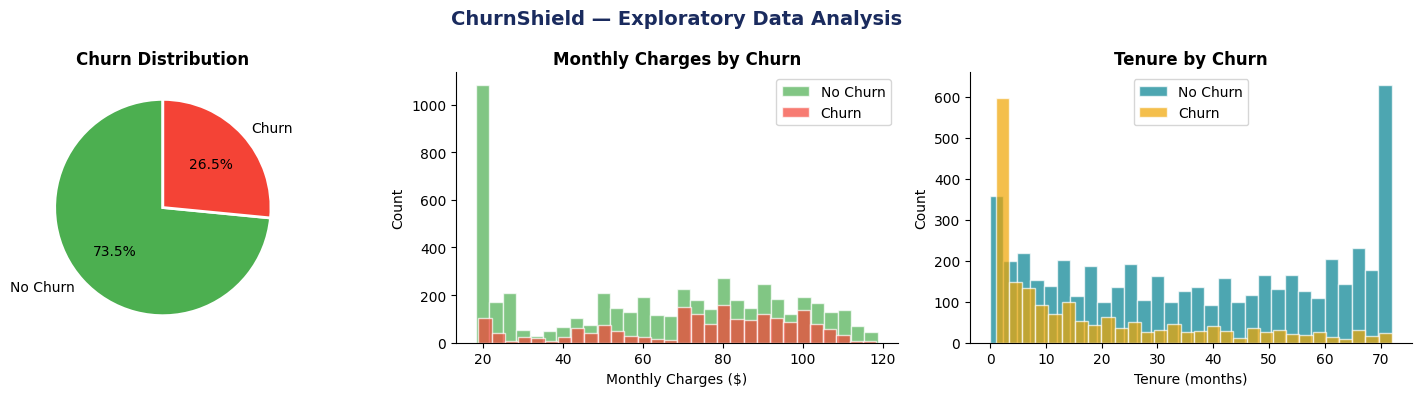

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ChurnShield — Exploratory Data Analysis', fontsize=14, fontweight='bold', color='#1A2B5E')

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution', fontweight='bold')

# Monthly charges by churn
no_churn = df[df['Churn'] == 'No']['MonthlyCharges']
yes_churn = df[df['Churn'] == 'Yes']['MonthlyCharges']
axes[1].hist(no_churn, bins=30, alpha=0.7, color='#4CAF50', label='No Churn', edgecolor='white')
axes[1].hist(yes_churn, bins=30, alpha=0.7, color='#F44336', label='Churn', edgecolor='white')
axes[1].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Tenure by churn
axes[2].hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.7, color='#028090', label='No Churn', edgecolor='white')
axes[2].hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.7, color='#F0A500', label='Churn', edgecolor='white')
axes[2].set_title('Tenure by Churn', fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Count')
axes[2].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Preprocessing

In [6]:
data = df.copy()

# Drop ID column
if 'customerID' in data.columns:
    data.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

# Label encode all categoricals — save encoders for later use in the UI
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Features & target
X = data.drop('Churn', axis=1)
y = data['Churn']

# Scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(' Preprocessing complete')
print(f'   Training samples : {X_train.shape[0]:,}')
print(f'   Testing samples  : {X_test.shape[0]:,}')
print(f'   Features         : {X_train.shape[1]}')

 Preprocessing complete
   Training samples : 5,634
   Testing samples  : 1,409
   Features         : 19


## 🤖 Step 5 — Model 1: Churn Prediction (Logistic Regression)

=== Model 1: Churn Prediction (Logistic Regression) ===
Accuracy: 79.91%

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



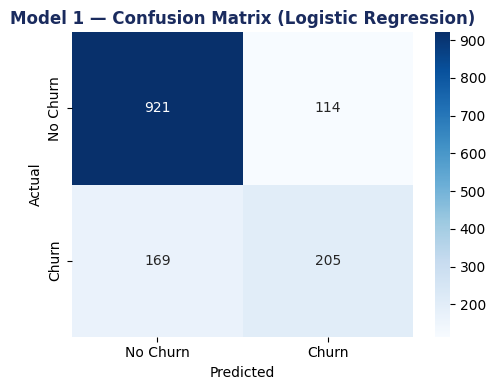

In [7]:
model1 = LogisticRegression(max_iter=1000, random_state=42)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)

print('=== Model 1: Churn Prediction (Logistic Regression) ===')
print(f'Accuracy: {acc1*100:.2f}%')
print()
print(classification_report(y_test, y_pred1, target_names=['No Churn', 'Churn']))

# Confusion matrix
cm1 = confusion_matrix(y_test, y_pred1)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('Model 1 — Confusion Matrix (Logistic Regression)', fontweight='bold', color='#1A2B5E')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Model 2: Retention Recommendation (Decision Tree)

In [8]:
RETENTION_MAP = {
    0: 'Offer a Discount',
    1: 'Upgrade Their Plan',
    2: 'Provide Priority Support',
    3: 'No Action Needed'
}

def assign_retention(idx):
    tenure  = df.loc[idx, 'tenure']        if 'tenure' in df.columns else 12
    monthly = df.loc[idx, 'MonthlyCharges'] if 'MonthlyCharges' in df.columns else 50
    contract = df.loc[idx, 'Contract']      if 'Contract' in df.columns else 'Month-to-month'
    if tenure <= 12 and monthly >= 70:              return 0
    elif 'Month-to-month' in str(contract):         return 1
    elif tenure > 24 and monthly < 50:              return 2
    else:                                           return 3

ret_train = pd.Series([assign_retention(i) for i in X_train.index], index=X_train.index)
ret_test  = pd.Series([assign_retention(i) for i in X_test.index],  index=X_test.index)

model2 = DecisionTreeClassifier(max_depth=5, random_state=42)
model2.fit(X_train, ret_train)
y_pred2 = model2.predict(X_test)
acc2    = accuracy_score(ret_test, y_pred2)

print('=== Model 2: Retention Recommendation (Decision Tree) ===')
print(f'Accuracy: {acc2*100:.2f}%')
print()
label_names = [RETENTION_MAP[i] for i in sorted(ret_train.unique())]
print(classification_report(ret_test, y_pred2, target_names=label_names))

=== Model 2: Retention Recommendation (Decision Tree) ===
Accuracy: 99.86%

                          precision    recall  f1-score   support

        Offer a Discount       0.99      1.00      0.99       177
      Upgrade Their Plan       1.00      1.00      1.00       602
Provide Priority Support       1.00      1.00      1.00       179
        No Action Needed       1.00      1.00      1.00       451

                accuracy                           1.00      1409
               macro avg       1.00      1.00      1.00      1409
            weighted avg       1.00      1.00      1.00      1409



## Model 3: Revenue Risk Assessment (Random Forest)

=== Model 3: Revenue Risk Assessment (Random Forest) ===
Accuracy: 100.00%

              precision    recall  f1-score   support

         LOW       1.00      1.00      1.00       461
      MEDIUM       1.00      1.00      1.00       440
        HIGH       1.00      1.00      1.00       508

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



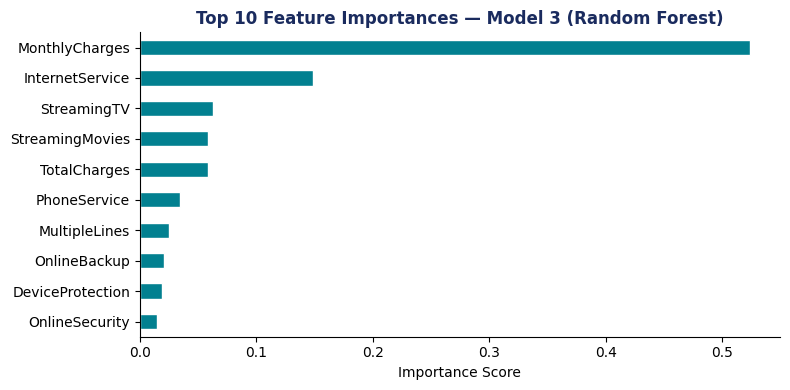

In [9]:
RISK_MAP = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}

def assign_risk(idx):
    monthly = df.loc[idx, 'MonthlyCharges'] if 'MonthlyCharges' in df.columns else 50
    if monthly >= 80:   return 2
    elif monthly >= 50: return 1
    else:               return 0

risk_train = pd.Series([assign_risk(i) for i in X_train.index], index=X_train.index)
risk_test  = pd.Series([assign_risk(i) for i in X_test.index],  index=X_test.index)

model3 = RandomForestClassifier(n_estimators=100, random_state=42)
model3.fit(X_train, risk_train)
y_pred3 = model3.predict(X_test)
acc3    = accuracy_score(risk_test, y_pred3)

print('=== Model 3: Revenue Risk Assessment (Random Forest) ===')
print(f'Accuracy: {acc3*100:.2f}%')
print()
print(classification_report(risk_test, y_pred3, target_names=['LOW', 'MEDIUM', 'HIGH']))

# Feature importance
importances = pd.Series(model3.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='#028090', edgecolor='white')
ax.set_title('Top 10 Feature Importances — Model 3 (Random Forest)', fontweight='bold', color='#1A2B5E')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

##  Model Comparison Summary

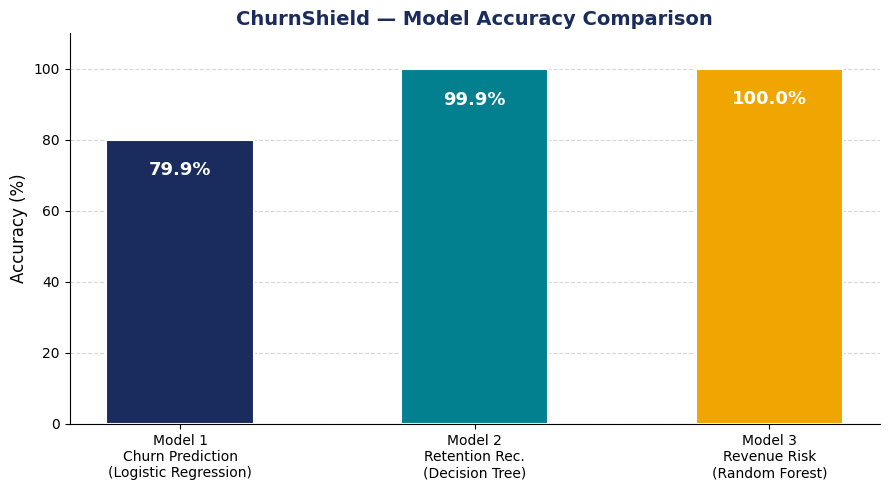

Model,Algorithm,Accuracy
Model 1 - Churn Prediction,Logistic Regression,79.91%
Model 2 - Retention Recommendation,Decision Tree,99.86%
Model 3 - Revenue Risk Assessment,Random Forest,100.00%


In [10]:
accs   = [acc1*100, acc2*100, acc3*100]
labels = ['Model 1\nChurn Prediction\n(Logistic Regression)',
          'Model 2\nRetention Rec.\n(Decision Tree)',
          'Model 3\nRevenue Risk\n(Random Forest)']
colors = ['#1A2B5E', '#028090', '#F0A500']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 6,
            f'{acc:.1f}%', ha='center', va='top', fontweight='bold',
            color='white', fontsize=13)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('ChurnShield — Model Accuracy Comparison', fontsize=14, fontweight='bold', color='#1A2B5E')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'Model'    : ['Model 1 - Churn Prediction', 'Model 2 - Retention Recommendation', 'Model 3 - Revenue Risk Assessment'],
    'Algorithm': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy' : [f'{a:.2f}%' for a in accs]
})
display(summary.style.hide(axis='index').set_caption('Model Comparison'))

## Save Models

In [11]:
joblib.dump(model1, 'churnshield_model1_prediction.pkl')
joblib.dump(model2, 'churnshield_model2_recommendation.pkl')
joblib.dump(model3, 'churnshield_model3_risk.pkl')
joblib.dump(scaler, 'churnshield_scaler.pkl')

print('All models saved')
print('   churnshield_model1_prediction.pkl')
print('   churnshield_model2_recommendation.pkl')
print('   churnshield_model3_risk.pkl')
print('   churnshield_scaler.pkl')

All models saved
   churnshield_model1_prediction.pkl
   churnshield_model2_recommendation.pkl
   churnshield_model3_risk.pkl
   churnshield_scaler.pkl


## Interactive Dashboard
> Fill in the customer's details below and click **Analyze Customer** to run all 3 models.

In [12]:
# ─────────────────────────────────────────────────────────────
# Encoding maps — must match LabelEncoder's alphabetical order
# ─────────────────────────────────────────────────────────────
ENCODE = {
    'gender':           {'Female': 0, 'Male': 1},
    'Partner':          {'No': 0, 'Yes': 1},
    'Dependents':       {'No': 0, 'Yes': 1},
    'PhoneService':     {'No': 0, 'Yes': 1},
    'MultipleLines':    {'No': 0, 'No phone service': 1, 'Yes': 2},
    'InternetService':  {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    'OnlineSecurity':   {'No': 0, 'No internet service': 1, 'Yes': 2},
    'OnlineBackup':     {'No': 0, 'No internet service': 1, 'Yes': 2},
    'DeviceProtection': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'TechSupport':      {'No': 0, 'No internet service': 1, 'Yes': 2},
    'StreamingTV':      {'No': 0, 'No internet service': 1, 'Yes': 2},
    'StreamingMovies':  {'No': 0, 'No internet service': 1, 'Yes': 2},
    'Contract':         {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'PaymentMethod':    {
        'Bank transfer (automatic)': 0,
        'Credit card (automatic)':   1,
        'Electronic check':          2,
        'Mailed check':              3
    },
}

RETENTION_DESC = {
    0: 'This customer is new and paying a high rate. A pricing incentive may keep them.',
    1: 'This customer is on a flexible contract. A better long-term plan may lock them in.',
    2: 'This is a loyal low-cost customer. Rewarding them with premium support builds loyalty.',
    3: 'This customer shows low churn signals. Continue monitoring normally.',
}

# ─────────────────────────────────────────────────────────────
# Widget style helper
# ─────────────────────────────────────────────────────────────
dd_layout = widgets.Layout(width='100%')
dd_style  = {'description_width': '160px'}

def dropdown(desc, opts, val=None):
    return widgets.Dropdown(
        description=desc, options=opts,
        value=val or opts[0],
        layout=dd_layout, style=dd_style
    )

def numbox(desc, val, mn, mx, step=1):
    return widgets.BoundedFloatText(
        description=desc, value=val,
        min=mn, max=mx, step=step,
        layout=dd_layout, style=dd_style
    )

# ─────────────────────────────────────────────────────────────
# All input widgets
# ─────────────────────────────────────────────────────────────
w_gender    = dropdown('Gender',             ['Female', 'Male'])
w_senior    = dropdown('Senior Citizen',     ['No', 'Yes'])
w_partner   = dropdown('Has Partner',        ['No', 'Yes'])
w_dependents= dropdown('Has Dependents',     ['No', 'Yes'])
w_tenure    = numbox  ('Tenure (months)',     3,   0, 120)

w_phone     = dropdown('Phone Service',      ['Yes', 'No'])
w_multiline = dropdown('Multiple Lines',     ['No', 'Yes', 'No phone service'])
w_internet  = dropdown('Internet Service',   ['Fiber optic', 'DSL', 'No'])
w_security  = dropdown('Online Security',    ['No', 'Yes', 'No internet service'])
w_backup    = dropdown('Online Backup',      ['No', 'Yes', 'No internet service'])
w_device    = dropdown('Device Protection',  ['No', 'Yes', 'No internet service'])
w_techsup   = dropdown('Tech Support',       ['No', 'Yes', 'No internet service'])
w_tv        = dropdown('Streaming TV',       ['No', 'Yes', 'No internet service'])
w_movies    = dropdown('Streaming Movies',   ['No', 'Yes', 'No internet service'])

w_contract  = dropdown('Contract Type',      ['Month-to-month', 'One year', 'Two year'])
w_paperless = dropdown('Paperless Billing',  ['Yes', 'No'])
w_payment   = dropdown('Payment Method',     ['Electronic check', 'Mailed check',
                                              'Bank transfer (automatic)', 'Credit card (automatic)'])
w_monthly   = numbox  ('Monthly Charges ($)', 90.0,  0, 200, 0.5)
w_total     = numbox  ('Total Charges ($)',   270.0, 0, 10000, 1)

btn_analyze = widgets.Button(
    description='🔍  Analyze Customer',
    button_style='',
    layout=widgets.Layout(width='100%', height='45px'),
    style={'button_color': '#028090', 'font_weight': 'bold'}
)
btn_reset = widgets.Button(
    description='↺  Reset',
    button_style='',
    layout=widgets.Layout(width='100%', height='45px'),
    style={'button_color': '#6B7280'}
)

output_area = widgets.Output()

# ─────────────────────────────────────────────────────────────
# Section header HTML helper
# ─────────────────────────────────────────────────────────────
def section_header(num, title):
    return widgets.HTML(f'''
        <div style="background:#1A2B5E;color:white;padding:8px 14px;
                    border-radius:8px;margin:10px 0 6px 0;display:flex;align-items:center;gap:10px;">
            <span style="background:#028090;border-radius:50%;width:24px;height:24px;
                         display:inline-flex;align-items:center;justify-content:center;
                         font-weight:bold;font-size:13px;">{num}</span>
            <b style="font-size:14px;">{title}</b>
        </div>
    ''')

# ─────────────────────────────────────────────────────────────
# Build the form layout
# ─────────────────────────────────────────────────────────────
col_w = '48%'

form = widgets.VBox([
    widgets.HTML('''
        <div style="background:#1A2B5E;color:white;padding:16px 20px;
                    border-radius:12px;margin-bottom:12px;">
            <div style="display:flex;align-items:center;gap:12px;">
                <span style="font-size:32px;">🛡️</span>
                <div>
                    <div style="font-size:22px;font-weight:bold;letter-spacing:1px;">ChurnShield</div>
                    <div style="font-size:12px;color:#CADCFC;">Multi-Model ML Customer Churn Decision Support System</div>
                </div>
            </div>
        </div>
        <div style="background:#E0F4F7;border:1px solid #028090;border-radius:8px;
                    padding:10px 14px;margin-bottom:8px;font-size:13px;color:#065A82;">
            ℹ️ Fill in the customer details below, then click <b>Analyze Customer</b>.
            Results will appear beneath the form.
        </div>
    '''),

    section_header('1', 'Basic Customer Info'),
    widgets.HBox([w_gender, w_senior],    layout=widgets.Layout(justify_content='space-between')),
    widgets.HBox([w_partner, w_dependents], layout=widgets.Layout(justify_content='space-between')),
    w_tenure,

    section_header('2', 'Subscribed Services'),
    widgets.HBox([w_phone, w_multiline],  layout=widgets.Layout(justify_content='space-between')),
    w_internet,
    widgets.HBox([w_security, w_backup],  layout=widgets.Layout(justify_content='space-between')),
    widgets.HBox([w_device, w_techsup],   layout=widgets.Layout(justify_content='space-between')),
    widgets.HBox([w_tv, w_movies],        layout=widgets.Layout(justify_content='space-between')),

    section_header('3', 'Contract & Billing'),
    w_contract,
    widgets.HBox([w_paperless, w_payment], layout=widgets.Layout(justify_content='space-between')),
    widgets.HBox([w_monthly, w_total],    layout=widgets.Layout(justify_content='space-between')),

    widgets.HTML('<div style="margin-top:10px;"></div>'),
    widgets.HBox([btn_analyze, btn_reset], layout=widgets.Layout(gap='10px')),
    output_area,
], layout=widgets.Layout(width='720px', padding='10px'))

# ─────────────────────────────────────────────────────────────
# Progress bar HTML helper
# ─────────────────────────────────────────────────────────────
def prob_bar(pct, color):
    return f'''
        <div style="background:#E5E7EB;border-radius:99px;height:10px;margin-top:6px;">
            <div style="background:{color};width:{pct:.0f}%;height:10px;
                        border-radius:99px;transition:width .4s ease;"></div>
        </div>
        <div style="font-size:11px;color:#6B7280;margin-top:2px;">{pct:.1f}%</div>
    '''

# ─────────────────────────────────────────────────────────────
# Prediction logic
# ─────────────────────────────────────────────────────────────
def run_prediction(btn):
    with output_area:
        clear_output(wait=True)

        # Build input row
        senior_val = 1 if w_senior.value == 'Yes' else 0
        row = np.array([[
            senior_val,
            ENCODE['gender'][w_gender.value],
            ENCODE['Partner'][w_partner.value],
            ENCODE['Dependents'][w_dependents.value],
            float(w_tenure.value),
            ENCODE['PhoneService'][w_phone.value],
            ENCODE['MultipleLines'][w_multiline.value],
            ENCODE['InternetService'][w_internet.value],
            ENCODE['OnlineSecurity'][w_security.value],
            ENCODE['OnlineBackup'][w_backup.value],
            ENCODE['DeviceProtection'][w_device.value],
            ENCODE['TechSupport'][w_techsup.value],
            ENCODE['StreamingTV'][w_tv.value],
            ENCODE['StreamingMovies'][w_movies.value],
            ENCODE['Contract'][w_contract.value],
            ENCODE['PaperlessBilling'][w_paperless.value],
            ENCODE['PaymentMethod'][w_payment.value],
            float(w_monthly.value),
            float(w_total.value),
        ]])

        X_input = scaler.transform(row)

        # Model 1
        churn_pred  = model1.predict(X_input)[0]
        churn_proba = model1.predict_proba(X_input)[0][1] * 100
        churn_yes   = churn_pred == 1

        # Model 2
        ret_pred  = model2.predict(X_input)[0]
        ret_label = RETENTION_MAP[ret_pred]
        ret_desc  = RETENTION_DESC[ret_pred]

        # Model 3
        risk_pred   = model3.predict(X_input)[0]
        risk_proba  = model3.predict_proba(X_input)[0][risk_pred] * 100
        risk_label  = RISK_MAP[risk_pred]
        risk_colors = {0: '#16A34A', 1: '#D97706', 2: '#DC2626'}
        risk_color  = risk_colors[risk_pred]
        risk_bg     = {0: '#F0FDF4', 1: '#FFFBEB', 2: '#FEF2F2'}[risk_pred]
        risk_border = {0: '#86EFAC', 1: '#FCD34D', 2: '#FCA5A5'}[risk_pred]

        churn_color  = '#DC2626' if churn_yes else '#16A34A'
        churn_bg     = '#FEF2F2' if churn_yes else '#F0FDF4'
        churn_border = '#FCA5A5' if churn_yes else '#86EFAC'
        churn_icon   = '⚠️ YES'  if churn_yes else '✅ NO'
        churn_msg    = 'This customer is at risk of leaving.' if churn_yes else 'This customer is likely to stay.'

        html = f'''
        <div style="width:700px;font-family:'Segoe UI',sans-serif;margin-top:16px;">

          <!-- Customer Profile Summary -->
          <div style="background:white;border:1px solid #E2E8F0;border-radius:10px;
                      padding:14px 18px;margin-bottom:12px;">
            <div style="font-size:13px;font-weight:700;color:#1A2B5E;margin-bottom:10px;">📋 Customer Profile</div>
            <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:10px;font-size:12px;">
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Tenure</div>
                   <div style="color:#1F2937;font-weight:500;">{int(w_tenure.value)} months</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Monthly Charges</div>
                   <div style="color:#1F2937;font-weight:500;">${w_monthly.value:.2f}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Total Charges</div>
                   <div style="color:#1F2937;font-weight:500;">${w_total.value:.2f}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Contract</div>
                   <div style="color:#1F2937;font-weight:500;">{w_contract.value}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Internet Service</div>
                   <div style="color:#1F2937;font-weight:500;">{w_internet.value}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Senior Citizen</div>
                   <div style="color:#1F2937;font-weight:500;">{w_senior.value}</div></div>
            </div>
          </div>

          <!-- Divider -->
          <div style="display:flex;align-items:center;gap:8px;margin:10px 0;">
            <div style="flex:1;height:1px;background:#E2E8F0;"></div>
            <div style="font-size:10px;font-weight:700;color:#9CA3AF;letter-spacing:2px;">SYSTEM RESULTS</div>
            <div style="flex:1;height:1px;background:#E2E8F0;"></div>
          </div>

          <!-- Model 1: Churn Prediction -->
          <div style="background:{churn_bg};border:2px solid {churn_border};
                      border-radius:10px;padding:14px 18px;margin-bottom:10px;">
            <div style="display:flex;justify-content:space-between;align-items:flex-start;">
              <div>
                <div style="font-size:10px;font-weight:700;color:{churn_color};
                            text-transform:uppercase;letter-spacing:1px;margin-bottom:4px;">
                  Model 1 · Logistic Regression
                </div>
                <div style="font-size:15px;font-weight:700;color:{churn_color};">Churn Prediction</div>
                <div style="font-size:12px;color:{churn_color};margin-top:4px;">{churn_msg}</div>
              </div>
              <div style="text-align:right;">
                <div style="font-size:26px;font-weight:900;color:{churn_color};">{churn_icon}</div>
              </div>
            </div>
            <div style="margin-top:10px;">
              <div style="font-size:11px;color:{churn_color};margin-bottom:2px;">Churn Probability</div>
              {prob_bar(churn_proba, churn_color)}
            </div>
          </div>

          <!-- Model 2: Retention -->
          <div style="background:#FFFBEB;border:2px solid #FCD34D;
                      border-radius:10px;padding:14px 18px;margin-bottom:10px;">
            <div style="display:flex;justify-content:space-between;align-items:flex-start;">
              <div style="flex:1;">
                <div style="font-size:10px;font-weight:700;color:#D97706;
                            text-transform:uppercase;letter-spacing:1px;margin-bottom:4px;">
                  Model 2 · Decision Tree
                </div>
                <div style="font-size:15px;font-weight:700;color:#D97706;">Retention Recommendation</div>
                <div style="font-size:12px;color:#92400E;margin-top:4px;">{ret_desc}</div>
              </div>
              <div style="text-align:right;min-width:fit-content;margin-left:12px;">
                <div style="font-size:15px;font-weight:900;color:#D97706;">💡 {ret_label}</div>
              </div>
            </div>
          </div>

          <!-- Model 3: Risk -->
          <div style="background:{risk_bg};border:2px solid {risk_border};
                      border-radius:10px;padding:14px 18px;margin-bottom:12px;">
            <div style="display:flex;justify-content:space-between;align-items:flex-start;">
              <div>
                <div style="font-size:10px;font-weight:700;color:{risk_color};
                            text-transform:uppercase;letter-spacing:1px;margin-bottom:4px;">
                  Model 3 · Random Forest
                </div>
                <div style="font-size:15px;font-weight:700;color:{risk_color};">Revenue Risk Assessment</div>
                <div style="font-size:12px;color:{risk_color};margin-top:4px;">
                  Losing this customer represents a <b>{risk_label}</b> financial risk.
                </div>
              </div>
              <div style="text-align:right;">
                <div style="font-size:22px;font-weight:900;color:{risk_color};">{risk_label}</div>
                <div style="font-size:12px;color:{risk_color};">{risk_proba:.1f}% confidence</div>
              </div>
            </div>
          </div>

          <!-- Summary Box -->
          <div style="background:#1A2B5E;border-radius:10px;padding:16px 20px;">
            <div style="font-size:11px;font-weight:700;color:#CADCFC;
                        text-transform:uppercase;letter-spacing:2px;margin-bottom:12px;">📊 Summary Report</div>
            <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:10px;text-align:center;">
              <div style="background:rgba(255,255,255,0.1);border-radius:8px;padding:12px 8px;">
                <div style="font-size:10px;color:#93C5FD;margin-bottom:4px;">Churn Prediction</div>
                <div style="font-size:20px;font-weight:900;color:{churn_color};">{'YES' if churn_yes else 'NO'}</div>
                <div style="font-size:10px;color:#93C5FD;margin-top:2px;">{churn_proba:.1f}% probability</div>
              </div>
              <div style="background:rgba(255,255,255,0.1);border-radius:8px;padding:12px 8px;">
                <div style="font-size:10px;color:#93C5FD;margin-bottom:4px;">Retention Action</div>
                <div style="font-size:13px;font-weight:700;color:#FCD34D;">{ret_label}</div>
              </div>
              <div style="background:rgba(255,255,255,0.1);border-radius:8px;padding:12px 8px;">
                <div style="font-size:10px;color:#93C5FD;margin-bottom:4px;">Revenue Risk</div>
                <div style="font-size:20px;font-weight:900;color:{risk_color};">{risk_label}</div>
                <div style="font-size:10px;color:#93C5FD;margin-top:2px;">{risk_proba:.1f}% confidence</div>
              </div>
            </div>
          </div>

        </div>
        '''
        display(HTML(html))

def reset_form(btn):
    with output_area:
        clear_output()

btn_analyze.on_click(run_prediction)
btn_reset.on_click(reset_form)

# ─────────────────────────────────────────────────────────────
# Display the dashboard
# ─────────────────────────────────────────────────────────────
display(form)

In [13]:
# ─────────────────────────────────────────────────────────────
# 🎲 Step 11 — Random Customer Analyzer
# ─────────────────────────────────────────────────────────────
import random

btn_random  = widgets.Button(
    description='🎲  Pick Random Customer',
    layout=widgets.Layout(width='360px', height='45px'),
    style={'button_color': '#1A2B5E', 'font_weight': 'bold'}
)
btn_reroll  = widgets.Button(
    description='🔀  Pick Another',
    layout=widgets.Layout(width='200px', height='45px'),
    style={'button_color': '#028090'}
)
btn_reroll.layout.display = 'none'   # hidden until first pick

random_output = widgets.Output()

# Keep track of last picked index so reroll always gives a different one
last_idx = {'val': None}

def analyze_random(btn):
    # Pick a random row from the ORIGINAL (unencoded) dataframe
    available = [i for i in df.index if i != last_idx['val']]
    idx = random.choice(available)
    last_idx['val'] = idx

    row_raw = df.loc[idx]   # original string values
    row_enc = data.drop('Churn', axis=1).loc[idx].values.reshape(1, -1)
    X_input = scaler.transform(row_enc)

    # ── Model 1 ──
    churn_pred  = model1.predict(X_input)[0]
    churn_proba = model1.predict_proba(X_input)[0][1] * 100
    churn_yes   = churn_pred == 1

    # ── Model 2 ──
    ret_pred  = model2.predict(X_input)[0]
    ret_label = RETENTION_MAP[ret_pred]
    ret_desc  = RETENTION_DESC[ret_pred]

    # ── Model 3 ──
    risk_pred  = model3.predict(X_input)[0]
    risk_proba = model3.predict_proba(X_input)[0][risk_pred] * 100
    risk_label = RISK_MAP[risk_pred]

    # ── Colors ──
    churn_color  = '#DC2626' if churn_yes else '#16A34A'
    churn_bg     = '#FEF2F2' if churn_yes else '#F0FDF4'
    churn_border = '#FCA5A5' if churn_yes else '#86EFAC'
    churn_icon   = '⚠️ YES'  if churn_yes else '✅ NO'
    churn_msg    = 'This customer is at risk of leaving.' if churn_yes else 'This customer is likely to stay.'

    risk_color  = {0: '#16A34A', 1: '#D97706', 2: '#DC2626'}[risk_pred]
    risk_bg     = {0: '#F0FDF4', 1: '#FFFBEB', 2: '#FEF2F2'}[risk_pred]
    risk_border = {0: '#86EFAC', 1: '#FCD34D', 2: '#FCA5A5'}[risk_pred]

    # ── Actual churn label from dataset ──
    actual_churn = row_raw['Churn'] if 'Churn' in row_raw else 'Unknown'
    correct      = ('YES' if churn_yes else 'NO') == actual_churn.upper()
    verdict_color = '#16A34A' if correct else '#DC2626'
    verdict_icon  = '✅ Correct' if correct else '❌ Incorrect'

    with random_output:
        clear_output(wait=True)
        display(HTML(f'''
        <div style="width:700px;font-family:'Segoe UI',sans-serif;margin-top:14px;">

          <!-- Random badge + customer ID -->
          <div style="background:#F3F4F6;border:1px solid #E5E7EB;border-radius:10px;
                      padding:10px 16px;margin-bottom:12px;
                      display:flex;justify-content:space-between;align-items:center;">
            <div>
              <span style="background:#1A2B5E;color:white;font-size:11px;font-weight:700;
                           padding:3px 10px;border-radius:99px;margin-right:8px;">🎲 RANDOM</span>
              <span style="font-size:13px;color:#374151;font-weight:600;">
                Customer ID: <code style="background:#E5E7EB;padding:2px 6px;border-radius:4px;">
                {row_raw.get("customerID", f"Row #{idx}")}</code>
              </span>
            </div>
            <div style="font-size:12px;color:#6B7280;">Dataset row {idx} of {len(df)-1}</div>
          </div>

          <!-- Customer Profile -->
          <div style="background:white;border:1px solid #E2E8F0;border-radius:10px;
                      padding:14px 18px;margin-bottom:12px;">
            <div style="font-size:13px;font-weight:700;color:#1A2B5E;margin-bottom:10px;">📋 Customer Profile</div>
            <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:10px;font-size:12px;">
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Tenure</div>
                   <div style="color:#1F2937;font-weight:500;">{int(row_raw.get("tenure", 0))} months</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Monthly Charges</div>
                   <div style="color:#1F2937;font-weight:500;">${float(row_raw.get("MonthlyCharges", 0)):.2f}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Total Charges</div>
                   <div style="color:#1F2937;font-weight:500;">${float(str(row_raw.get("TotalCharges", 0)).strip() or 0):.2f}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Contract</div>
                   <div style="color:#1F2937;font-weight:500;">{row_raw.get("Contract", "—")}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Internet Service</div>
                   <div style="color:#1F2937;font-weight:500;">{row_raw.get("InternetService", "—")}</div></div>
              <div><div style="color:#9CA3AF;font-size:10px;font-weight:600;text-transform:uppercase;">Payment Method</div>
                   <div style="color:#1F2937;font-weight:500;">{row_raw.get("PaymentMethod", "—")}</div></div>
            </div>
          </div>

          <!-- Divider -->
          <div style="display:flex;align-items:center;gap:8px;margin:10px 0;">
            <div style="flex:1;height:1px;background:#E2E8F0;"></div>
            <div style="font-size:10px;font-weight:700;color:#9CA3AF;letter-spacing:2px;">SYSTEM RESULTS</div>
            <div style="flex:1;height:1px;background:#E2E8F0;"></div>
          </div>

          <!-- Model 1 -->
          <div style="background:{churn_bg};border:2px solid {churn_border};
                      border-radius:10px;padding:14px 18px;margin-bottom:10px;">
            <div style="display:flex;justify-content:space-between;align-items:flex-start;">
              <div>
                <div style="font-size:10px;font-weight:700;color:{churn_color};
                            text-transform:uppercase;letter-spacing:1px;margin-bottom:4px;">
                  Model 1 · Logistic Regression
                </div>
                <div style="font-size:15px;font-weight:700;color:{churn_color};">Churn Prediction</div>
                <div style="font-size:12px;color:{churn_color};margin-top:4px;">{churn_msg}</div>
              </div>
              <div style="text-align:right;">
                <div style="font-size:26px;font-weight:900;color:{churn_color};">{churn_icon}</div>
              </div>
            </div>
            <div style="margin-top:10px;">
              <div style="font-size:11px;color:{churn_color};margin-bottom:2px;">Churn Probability</div>
              <div style="background:#E5E7EB;border-radius:99px;height:10px;">
                <div style="background:{churn_color};width:{churn_proba:.0f}%;height:10px;border-radius:99px;"></div>
              </div>
              <div style="font-size:11px;color:#6B7280;margin-top:2px;">{churn_proba:.1f}%</div>
            </div>
          </div>

          <!-- Model 2 -->
          <div style="background:#FFFBEB;border:2px solid #FCD34D;
                      border-radius:10px;padding:14px 18px;margin-bottom:10px;">
            <div style="display:flex;justify-content:space-between;align-items:flex-start;">
              <div style="flex:1;">
                <div style="font-size:10px;font-weight:700;color:#D97706;
                            text-transform:uppercase;letter-spacing:1px;margin-bottom:4px;">
                  Model 2 · Decision Tree
                </div>
                <div style="font-size:15px;font-weight:700;color:#D97706;">Retention Recommendation</div>
                <div style="font-size:12px;color:#92400E;margin-top:4px;">{ret_desc}</div>
              </div>
              <div style="text-align:right;min-width:fit-content;margin-left:12px;">
                <div style="font-size:15px;font-weight:900;color:#D97706;">💡 {ret_label}</div>
              </div>
            </div>
          </div>

          <!-- Model 3 -->
          <div style="background:{risk_bg};border:2px solid {risk_border};
                      border-radius:10px;padding:14px 18px;margin-bottom:12px;">
            <div style="display:flex;justify-content:space-between;align-items:flex-start;">
              <div>
                <div style="font-size:10px;font-weight:700;color:{risk_color};
                            text-transform:uppercase;letter-spacing:1px;margin-bottom:4px;">
                  Model 3 · Random Forest
                </div>
                <div style="font-size:15px;font-weight:700;color:{risk_color};">Revenue Risk Assessment</div>
                <div style="font-size:12px;color:{risk_color};margin-top:4px;">
                  Losing this customer represents a <b>{risk_label}</b> financial risk.
                </div>
              </div>
              <div style="text-align:right;">
                <div style="font-size:22px;font-weight:900;color:{risk_color};">{risk_label}</div>
                <div style="font-size:12px;color:{risk_color};">{risk_proba:.1f}% confidence</div>
              </div>
            </div>
          </div>

          <!-- Actual vs Predicted verdict -->
          <div style="background:white;border:1px solid #E2E8F0;border-radius:10px;
                      padding:12px 18px;margin-bottom:12px;
                      display:flex;justify-content:space-between;align-items:center;">
            <div style="font-size:12px;color:#6B7280;">
              <b style="color:#1A2B5E;">Actual churn</b> from dataset:
              <span style="font-weight:700;color:{'#DC2626' if actual_churn.lower()=='yes' else '#16A34A'};">
                {actual_churn.upper()}
              </span>
            </div>
            <div style="font-size:12px;font-weight:700;color:{verdict_color};">
              Model prediction was {verdict_icon}
            </div>
          </div>

          <!-- Summary -->
          <div style="background:#1A2B5E;border-radius:10px;padding:16px 20px;">
            <div style="font-size:11px;font-weight:700;color:#CADCFC;
                        text-transform:uppercase;letter-spacing:2px;margin-bottom:12px;">📊 Summary Report</div>
            <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:10px;text-align:center;">
              <div style="background:rgba(255,255,255,0.1);border-radius:8px;padding:12px 8px;">
                <div style="font-size:10px;color:#93C5FD;margin-bottom:4px;">Churn Prediction</div>
                <div style="font-size:20px;font-weight:900;color:{churn_color};">{'YES' if churn_yes else 'NO'}</div>
                <div style="font-size:10px;color:#93C5FD;margin-top:2px;">{churn_proba:.1f}% probability</div>
              </div>
              <div style="background:rgba(255,255,255,0.1);border-radius:8px;padding:12px 8px;">
                <div style="font-size:10px;color:#93C5FD;margin-bottom:4px;">Retention Action</div>
                <div style="font-size:13px;font-weight:700;color:#FCD34D;">{ret_label}</div>
              </div>
              <div style="background:rgba(255,255,255,0.1);border-radius:8px;padding:12px 8px;">
                <div style="font-size:10px;color:#93C5FD;margin-bottom:4px;">Revenue Risk</div>
                <div style="font-size:20px;font-weight:900;color:{risk_color};">{risk_label}</div>
                <div style="font-size:10px;color:#93C5FD;margin-top:2px;">{risk_proba:.1f}% confidence</div>
              </div>
            </div>
          </div>

        </div>
        '''))

    # Show the reroll button after first pick
    btn_reroll.layout.display = 'inline-flex'

btn_random.on_click(analyze_random)
btn_reroll.on_click(analyze_random)

display(widgets.VBox([
    widgets.HTML('''
        <div style="font-family:'Segoe UI',sans-serif;margin-bottom:10px;">
          <div style="font-size:16px;font-weight:700;color:#1A2B5E;margin-bottom:4px;">
            🎲 Random Customer Analyzer
          </div>
          <div style="font-size:12px;color:#6B7280;">
            Picks a real customer from the dataset and runs them through all 3 models.
            Includes the actual churn label so you can check if the model got it right.
          </div>
        </div>
    '''),
    widgets.HBox([btn_random, btn_reroll], layout=widgets.Layout(gap='10px')),
    random_output,
]))